# 125M1H026_ADS_Ex_Lab_T2_A2
## Student Grades Explorer

This notebook analyses the provided `grades.csv` dataset and prepares the code for a Streamlit web application.

The application includes:
- loading and previewing the grades dataset
- selecting a subject from a dropdown
- mean, median, and standard deviation of final scores for the selected subject
- a boxplot comparing final score distributions across subjects
- a scatterplot of Test1 and Final scores


## 1. Import libraries

Pandas is used for loading and analysing the dataset. NumPy is used for numerical calculations, while Seaborn and Matplotlib are used for visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and inspect the dataset

Before building the visualisations, the dataset is checked for its structure, data types, missing values, and duplicate records.

In [3]:
grades_data = pd.read_csv("./data/grades.csv")

grades_data.head()

,StudentID,Subject,Test1,Test2,Final
0,1,Math,97,60,62
1,2,Math,59,49,62
2,3,Science,71,74,77
3,4,Math,73,71,76
4,5,Math,65,71,82


In [4]:
print("Dataset shape:", grades_data.shape)
print("\nColumn data types:")
print(grades_data.dtypes)
print("\nMissing values:")
print(grades_data.isnull().sum())
print("\nDuplicate rows:", grades_data.duplicated().sum())

Dataset shape: (100, 5)

Column data types:
StudentID    int64
Subject        str
Test1        int64
Test2        int64
Final        int64
dtype: object

Missing values:
StudentID    0
Subject      0
Test1        0
Test2        0
Final        0
dtype: int64

Duplicate rows: 0


### Dataset observations

The provided dataset contains 100 student records and 5 columns:

- `StudentID`
- `Subject`
- `Test1`
- `Test2`
- `Final`

The dataset contains three subjects: Math, Science, and English. No missing values or duplicate rows were found.

In [5]:
print("Students per subject:")
print(grades_data["Subject"].value_counts())

Students per subject:
Subject
Math       36
Science    33
English    31
Name: count, dtype: int64


## 3. Preview the grades data

This is the same type of preview that will be displayed in the Streamlit application.

In [6]:
grades_data.head(10)

,StudentID,Subject,Test1,Test2,Final
0,1,Math,97,60,62
1,2,Math,59,49,62
2,3,Science,71,74,77
3,4,Math,73,71,76
4,5,Math,65,71,82
5,6,English,82,53,51
6,7,Science,54,84,97
7,8,Science,58,78,98
8,9,Math,51,99,50
9,10,Science,63,82,58


## 4. Select a subject and calculate summary statistics

For the notebook analysis, one subject is selected manually. In the Streamlit application, the same selection is made through a dropdown menu.

The required statistics are calculated from the `Final` score.

In [ ]:
selected_subject = "Math"

selected_subject_data = grades_data[
    grades_data["Subject"] == selected_subject
]

mean_final_score = selected_subject_data["Final"].mean()
median_final_score = selected_subject_data["Final"].median()
standard_deviation_final_score = selected_subject_data["Final"].std()

print(f"Selected subject: {selected_subject}")
print(f"Mean final score: {mean_final_score:.2f}")
print(f"Median final score: {median_final_score:.2f}")
print(f"Standard deviation: {standard_deviation_final_score:.2f}")

Selected subject: Math
Mean final score: 69.42
Median final score: 68.50
Standard deviation: 14.83


## 5. Compare final score distributions across subjects

A boxplot is used to compare the distribution of final scores for Math, Science, and English.

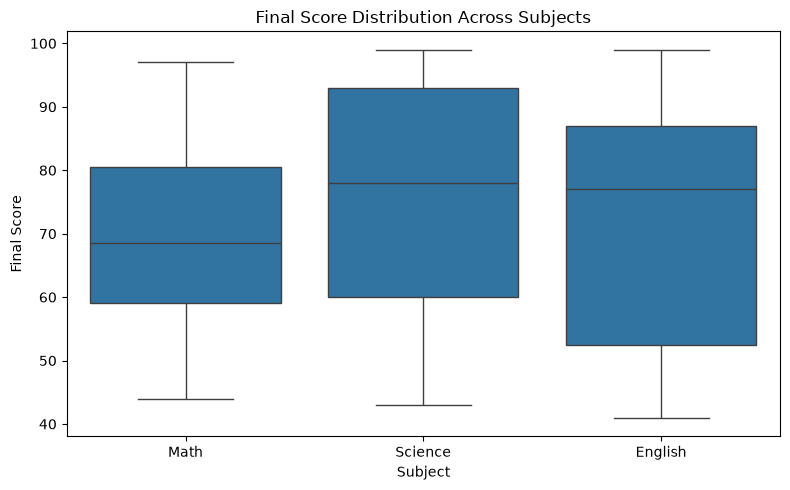

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=grades_data, x="Subject", y="Final")
plt.title("Final Score Distribution Across Subjects")
plt.xlabel("Subject")
plt.ylabel("Final Score")
plt.tight_layout()
plt.show()

## 6. Explore the relationship between Test1 and Final scores

The scatterplot uses the selected subject and shows whether higher Test1 scores are associated with higher Final scores.

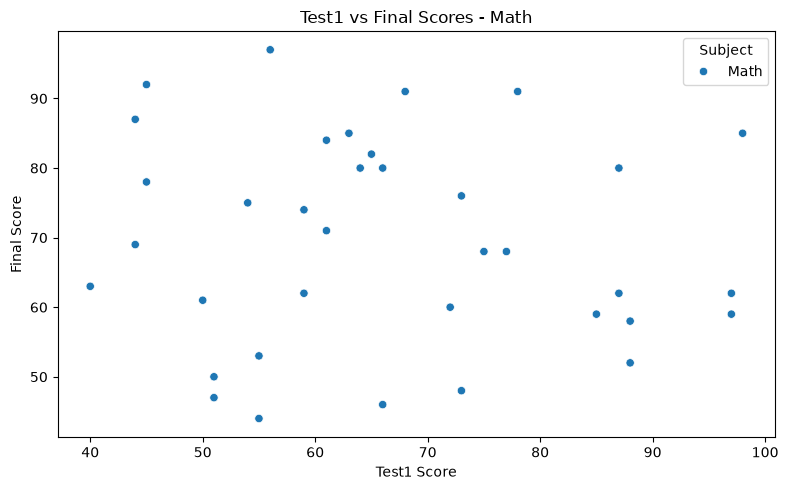

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=selected_subject_data,
    x="Test1",
    y="Final",
    hue="Subject"
)
plt.title(f"Test1 vs Final Scores - {selected_subject}")
plt.xlabel("Test1 Score")
plt.ylabel("Final Score")
plt.tight_layout()
plt.show()

# Streamlit Web Application

Save the following code as `T2_app.py` in the same folder as `grades.csv`.

Run the application from PowerShell using:

`python -m streamlit run .\T2_app.py`

The app uses a dropdown for subject selection and updates the summary statistics and scatterplot based on the selected subject.

## Conclusion

The analysis shows how student scores can be explored subject by subject. The Streamlit application provides an interactive subject selector, summary statistics for final scores, a comparison of score distributions across all subjects, and a Test1 versus Final score scatterplot for the selected subject.